In [4]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
import sys
import bachclue as bc
import time

In [5]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=200, facecolor='white')

## Baptiste Stage6

In [6]:
adata = sc.read_h5ad("datasets/Baptiste_data/stage6.h5ad")

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [10]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,replicate,percent.rb,percent.mt,integrated_snn_res.0.5,seurat_clusters
rep1_AAACGAAGTATGGAAT-1,rep1,2867.0,973,1.0,25.671434,3.836763,4,4
rep1_AAACGAAGTGAATAAC-1,rep1,4511.0,1283,1.0,34.138772,5.253824,4,4
rep1_AAAGAACAGTGTACCT-1,rep1,6293.0,1341,1.0,19.180041,10.805657,3,3
rep1_AAAGGGCTCAGGGATG-1,rep1,2444.0,822,1.0,34.983633,8.346972,1,1
rep1_AAAGGGCTCGTTTACT-1,rep1,2351.0,830,1.0,29.561889,9.612931,0,0
...,...,...,...,...,...,...,...,...
rep3_TTTGGAGAGTCTCCTC-1,rep3,4178.0,1174,3.0,21.373863,12.685495,5,5
rep3_TTTGGTTTCACTCCGT-1,rep3,39169.0,3960,3.0,33.942659,10.475121,3,3
rep3_TTTGTTGAGCAACCAG-1,rep3,2229.0,753,3.0,30.731270,5.293854,4,4
rep3_TTTGTTGTCCAGTGTA-1,rep3,2350.0,787,3.0,34.808511,7.531915,8,8


In [15]:
sorted(adata.obs['seurat_clusters'].unique())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [17]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Performing 19 parallel clusterings
Using 19/32 CPU cores
Starting parallel computation with Joblib using 19 cores...

Best resolution: 0.10


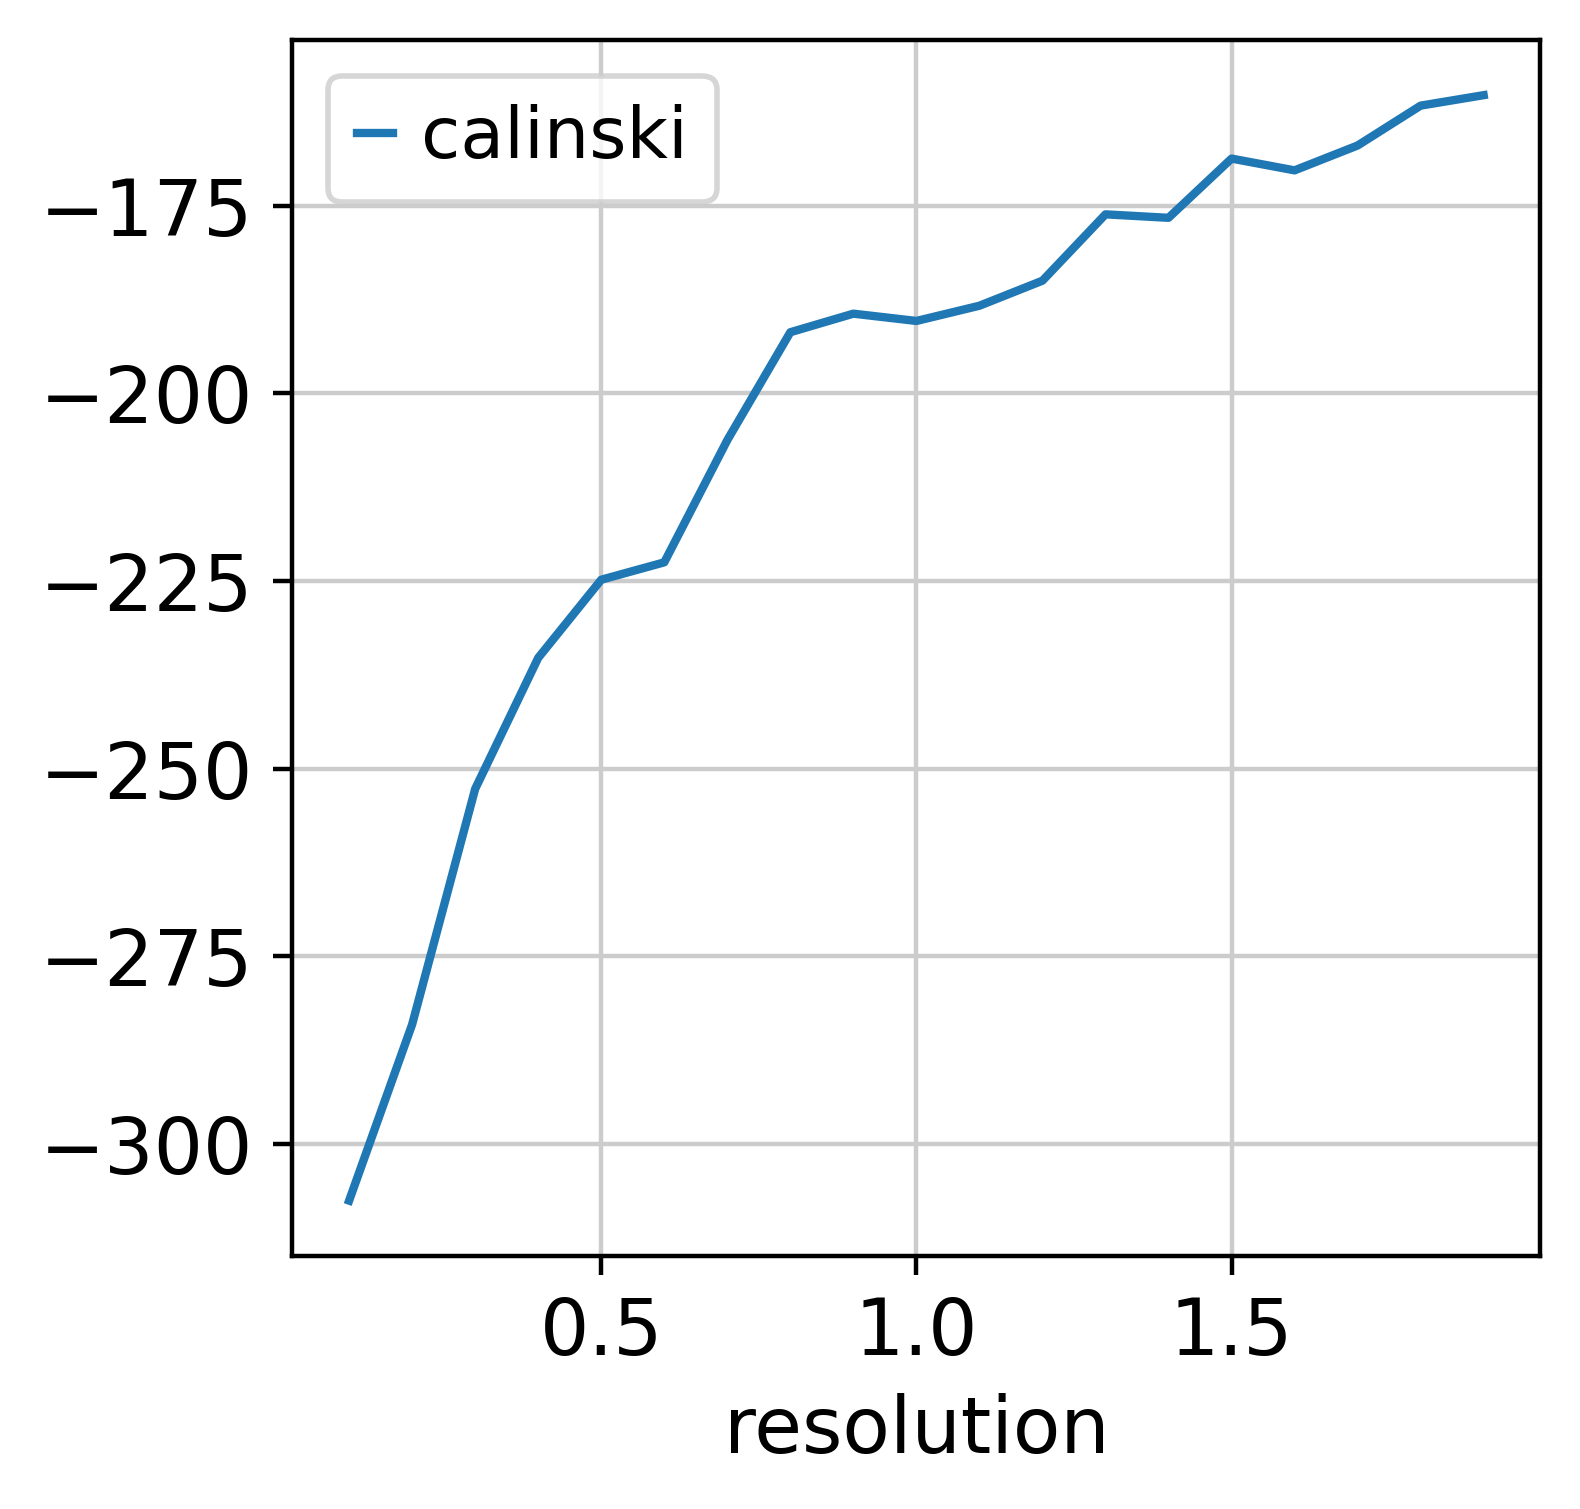

In [18]:
a = bc.clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.0,step=0.1, plot=True, dim_reduction = 'pca')

Performing 19 parallel clusterings
Using 19/32 CPU cores
Starting parallel computation with Joblib using 19 cores...

Best resolution: 1.70


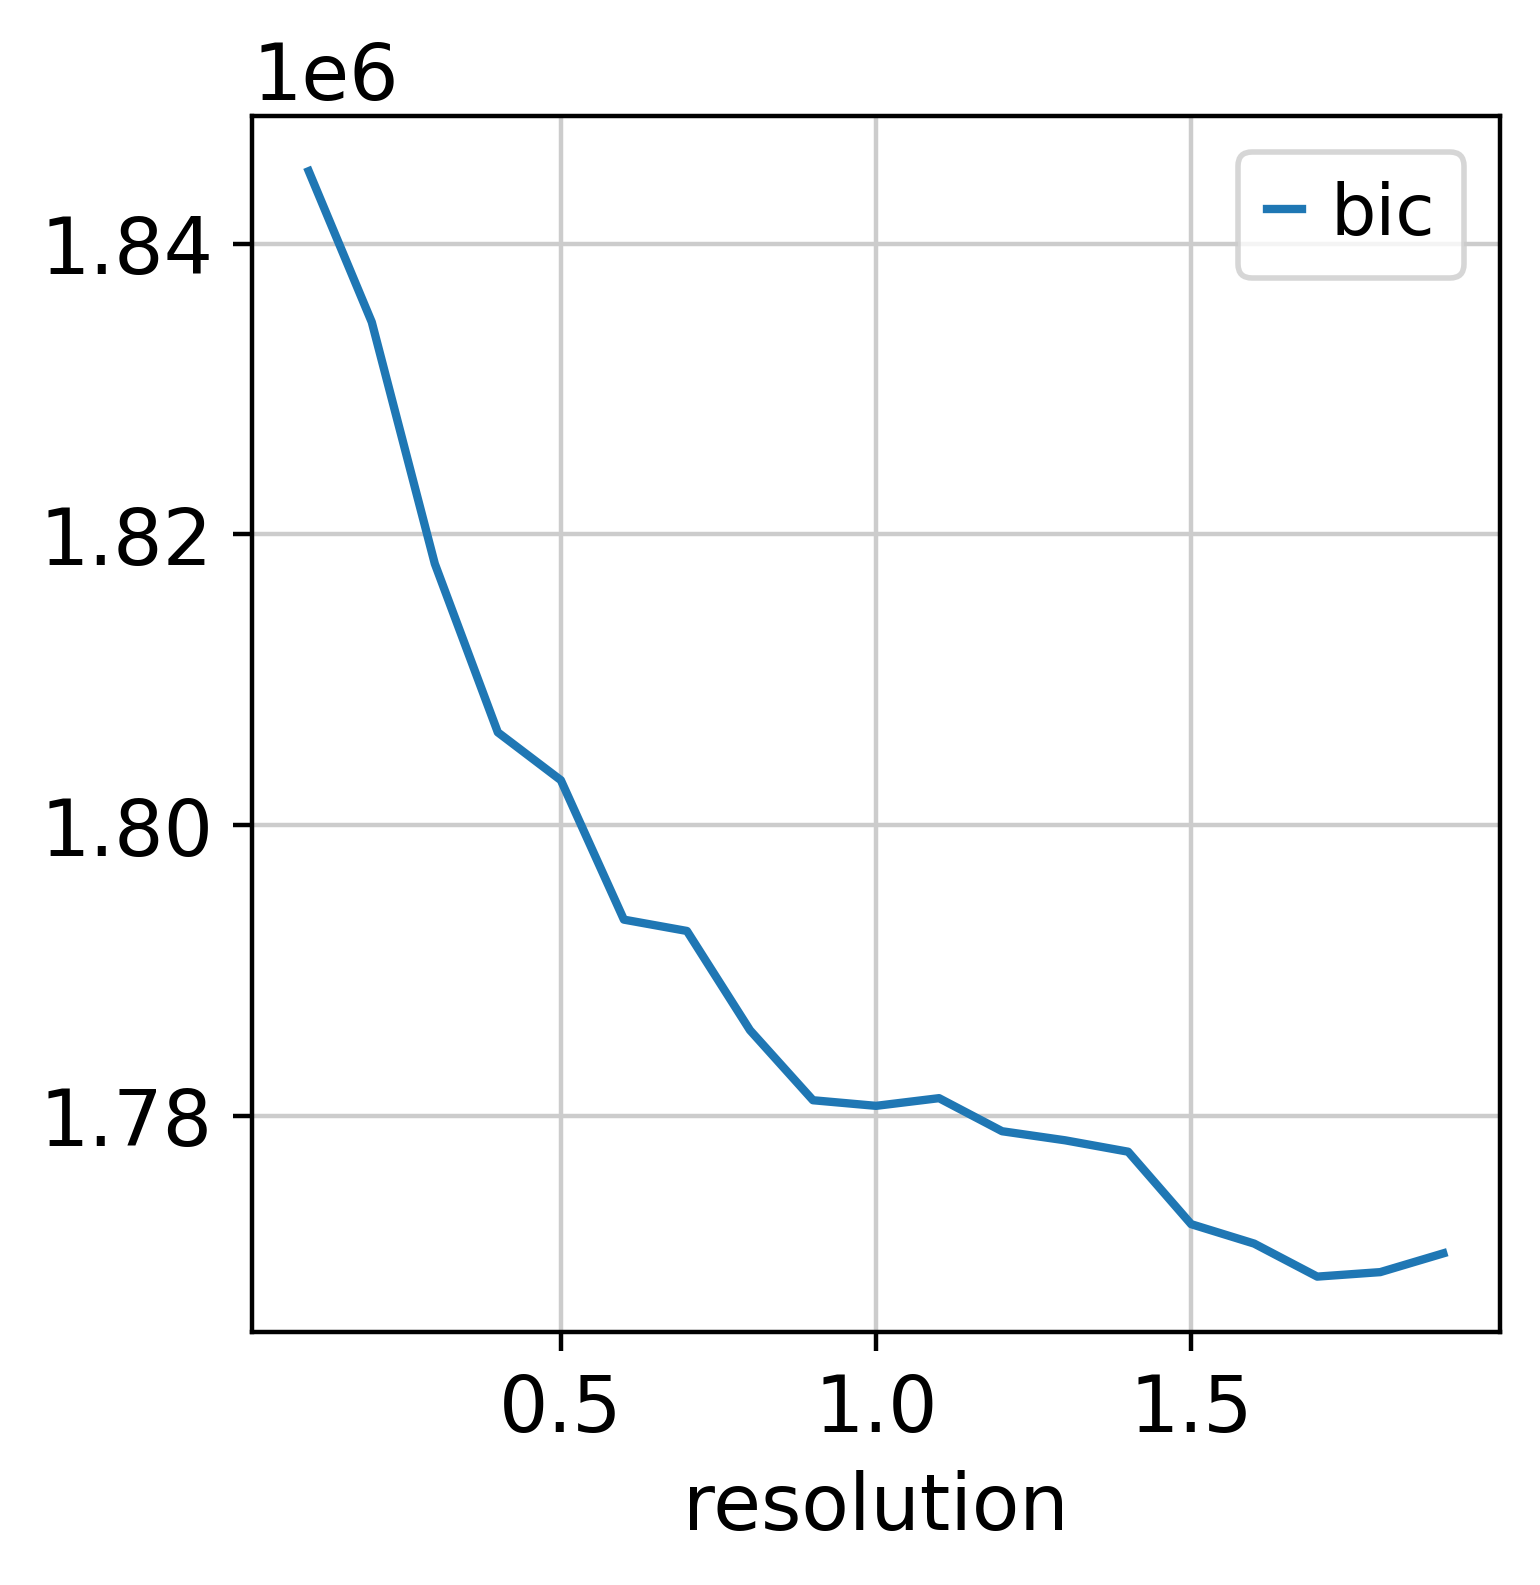

In [20]:
b = bc.clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.0,step=0.1, plot=True, dim_reduction = 'pca')

Performing 19 parallel clusterings
Using 19/32 CPU cores
Starting parallel computation with Joblib using 19 cores...

Best resolution: 0.40


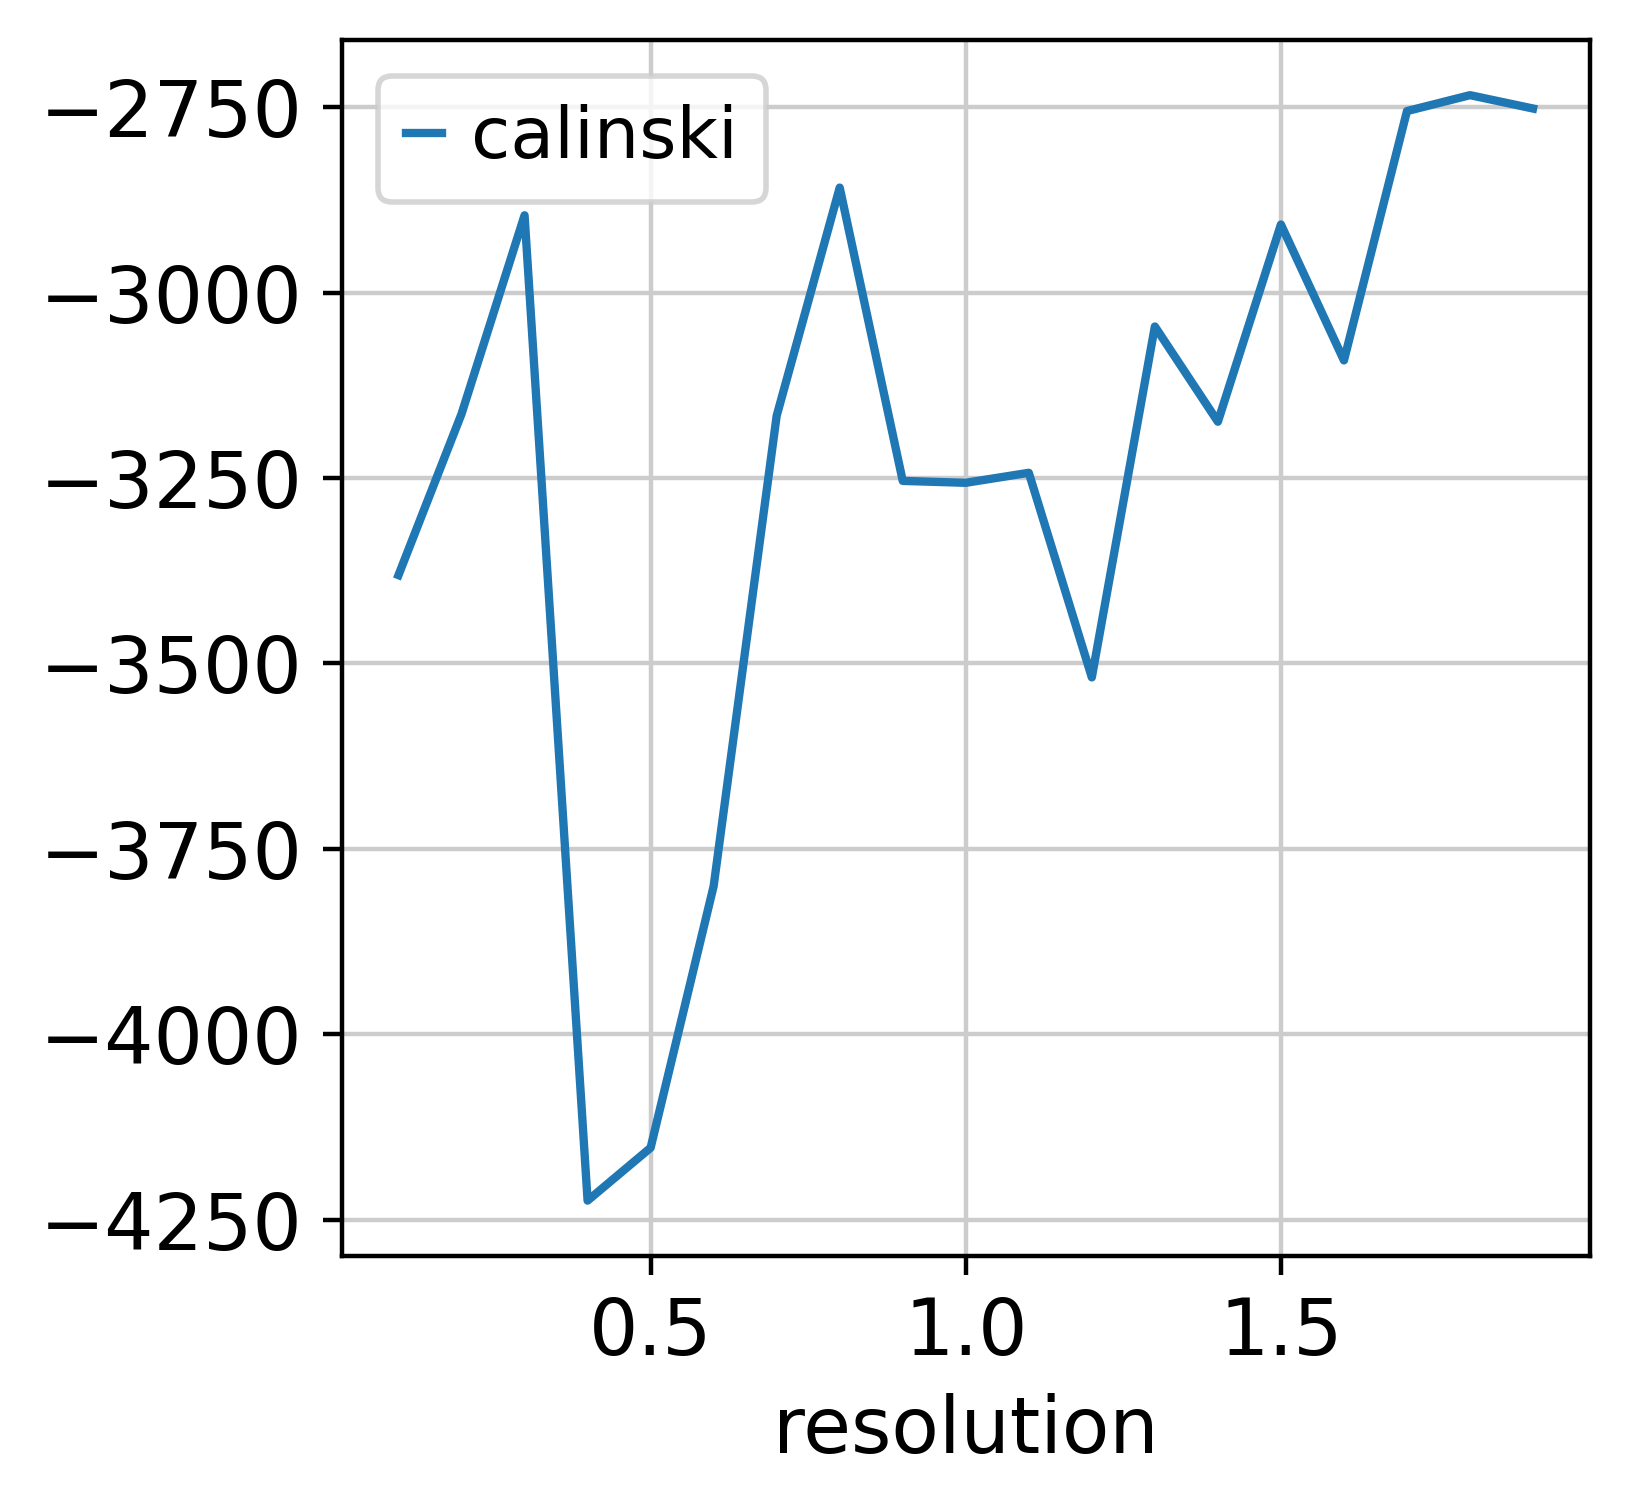

In [21]:
c = bc.clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.0,step=0.1, plot=True, dim_reduction = 'umap')

Performing 19 parallel clusterings
Using 19/32 CPU cores
Starting parallel computation with Joblib using 19 cores...

Best resolution: 0.10


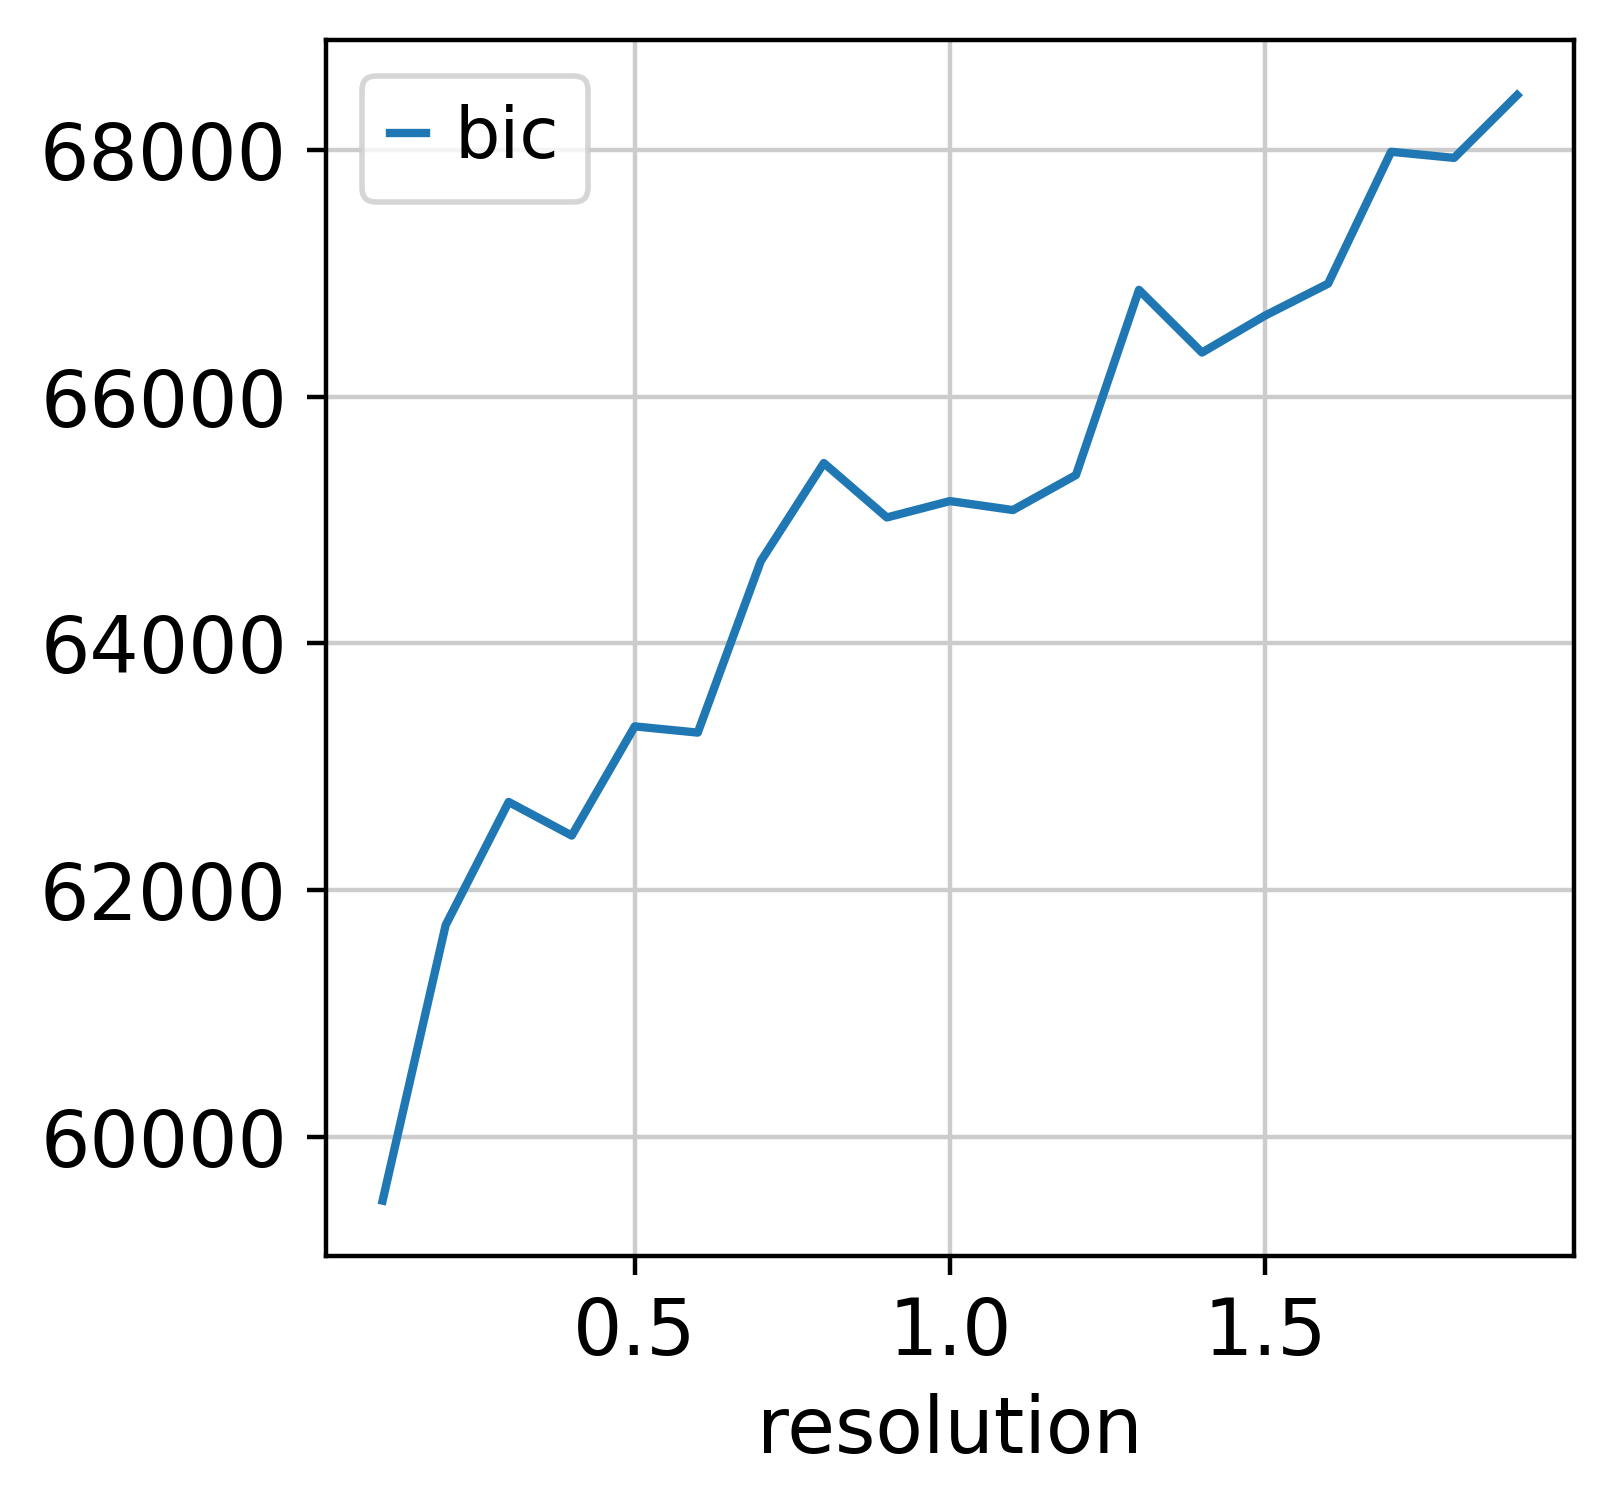

In [22]:
d = bc.clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.0,step=0.1, plot=True, dim_reduction = 'umap')

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


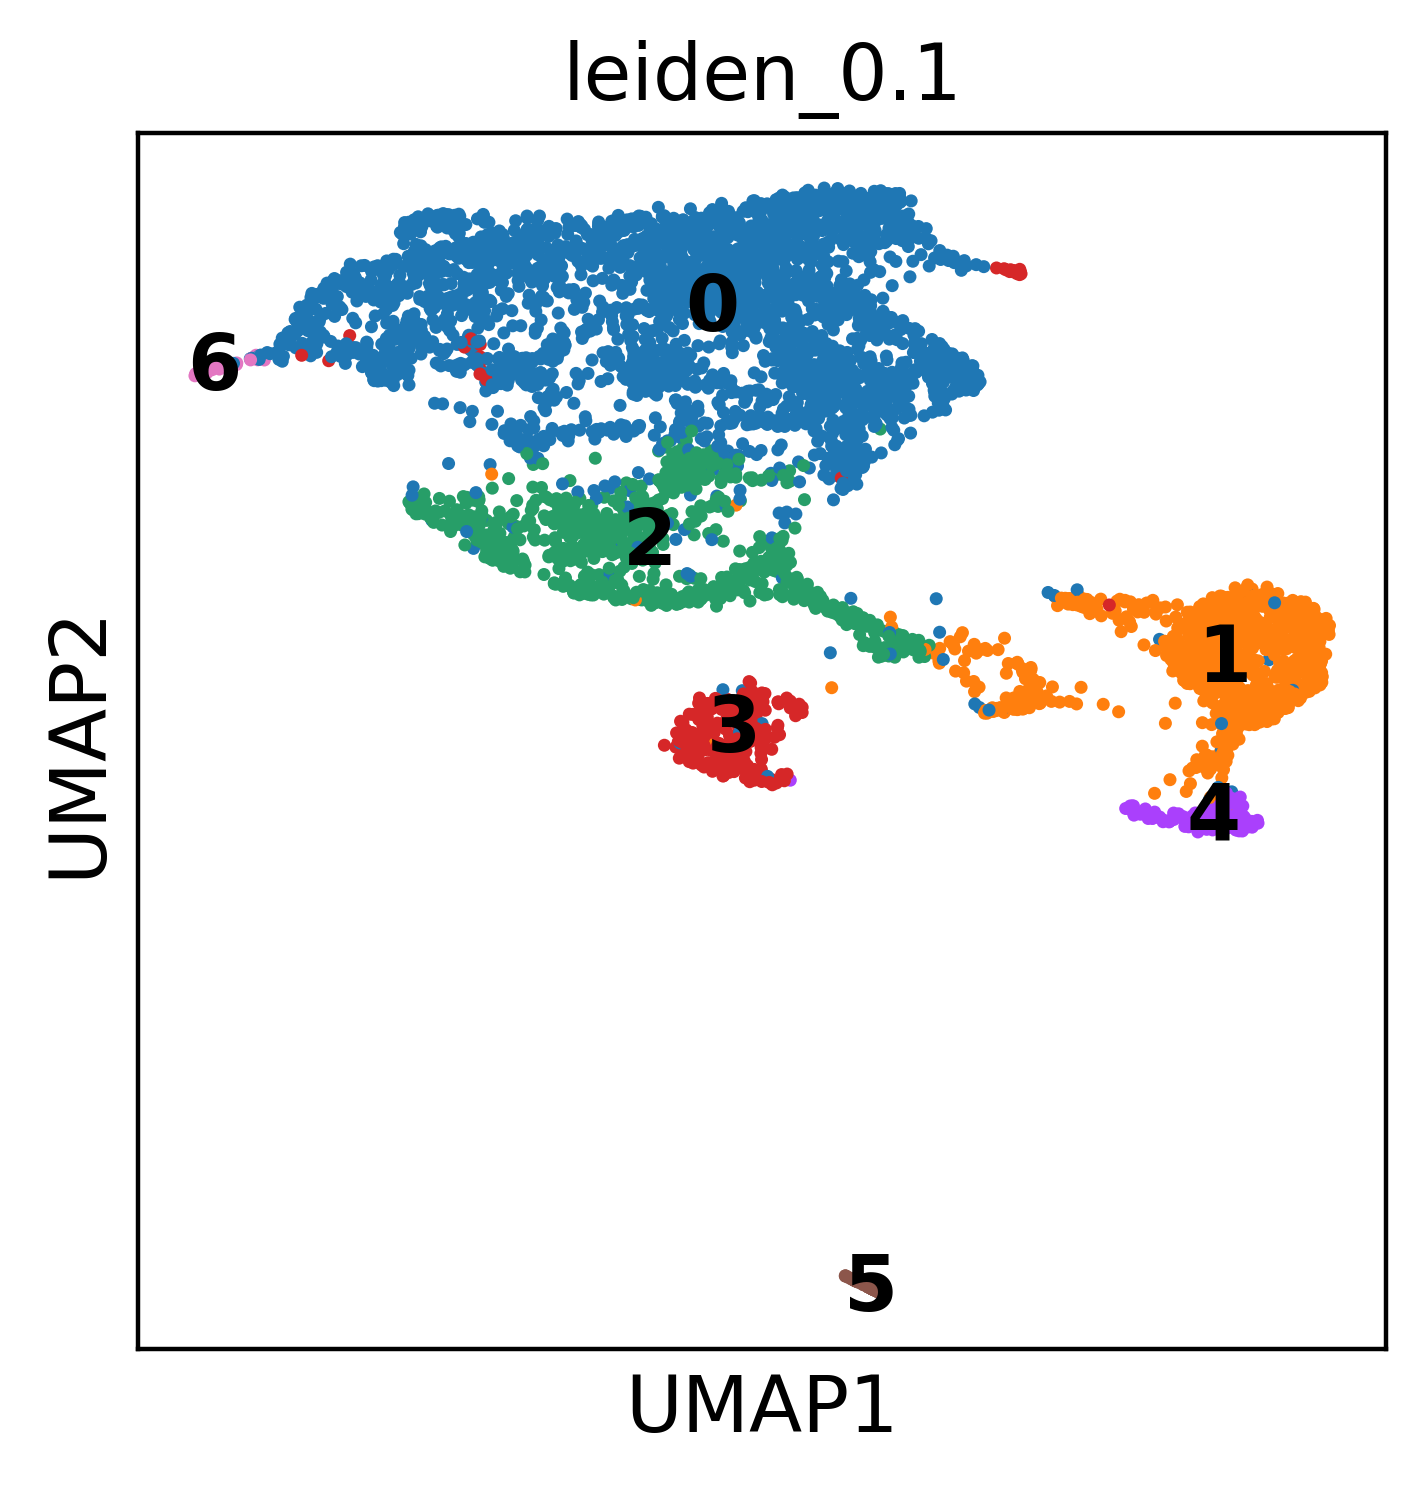

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


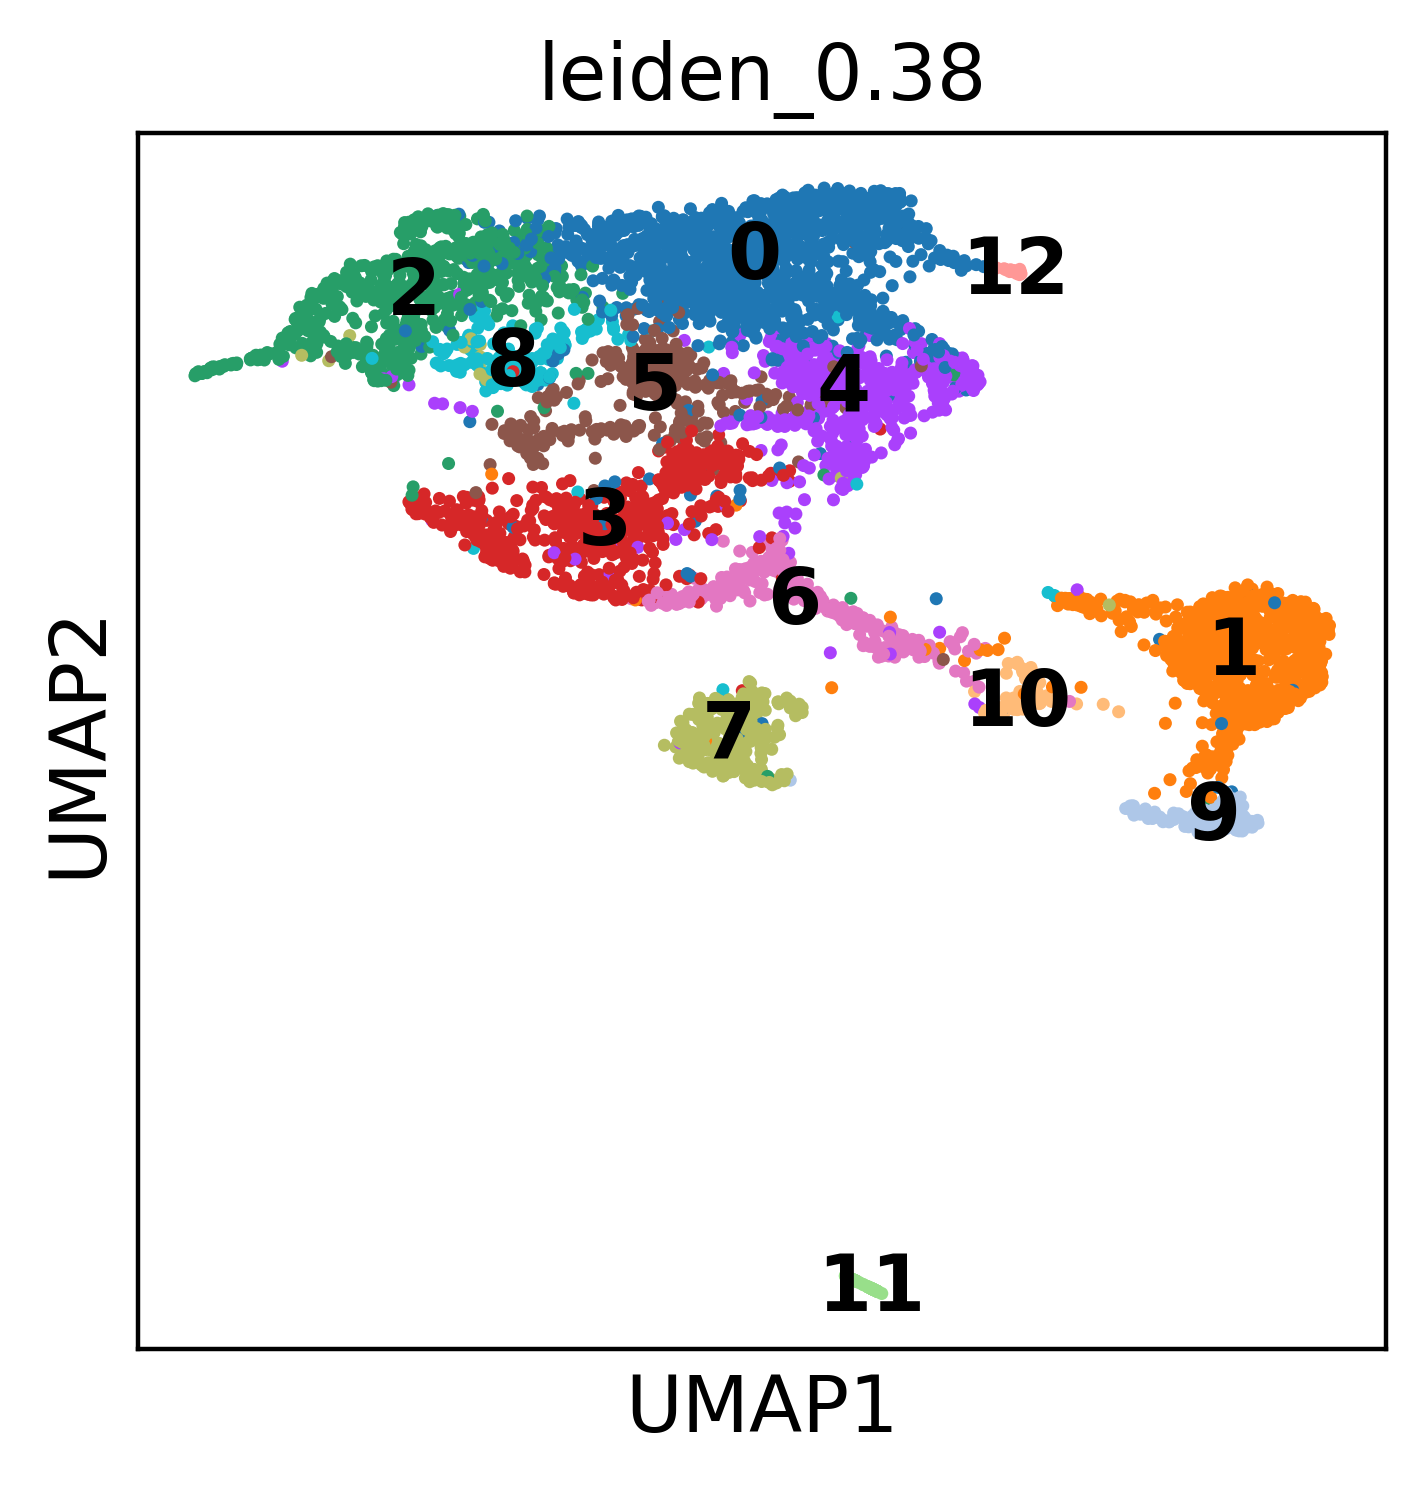

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


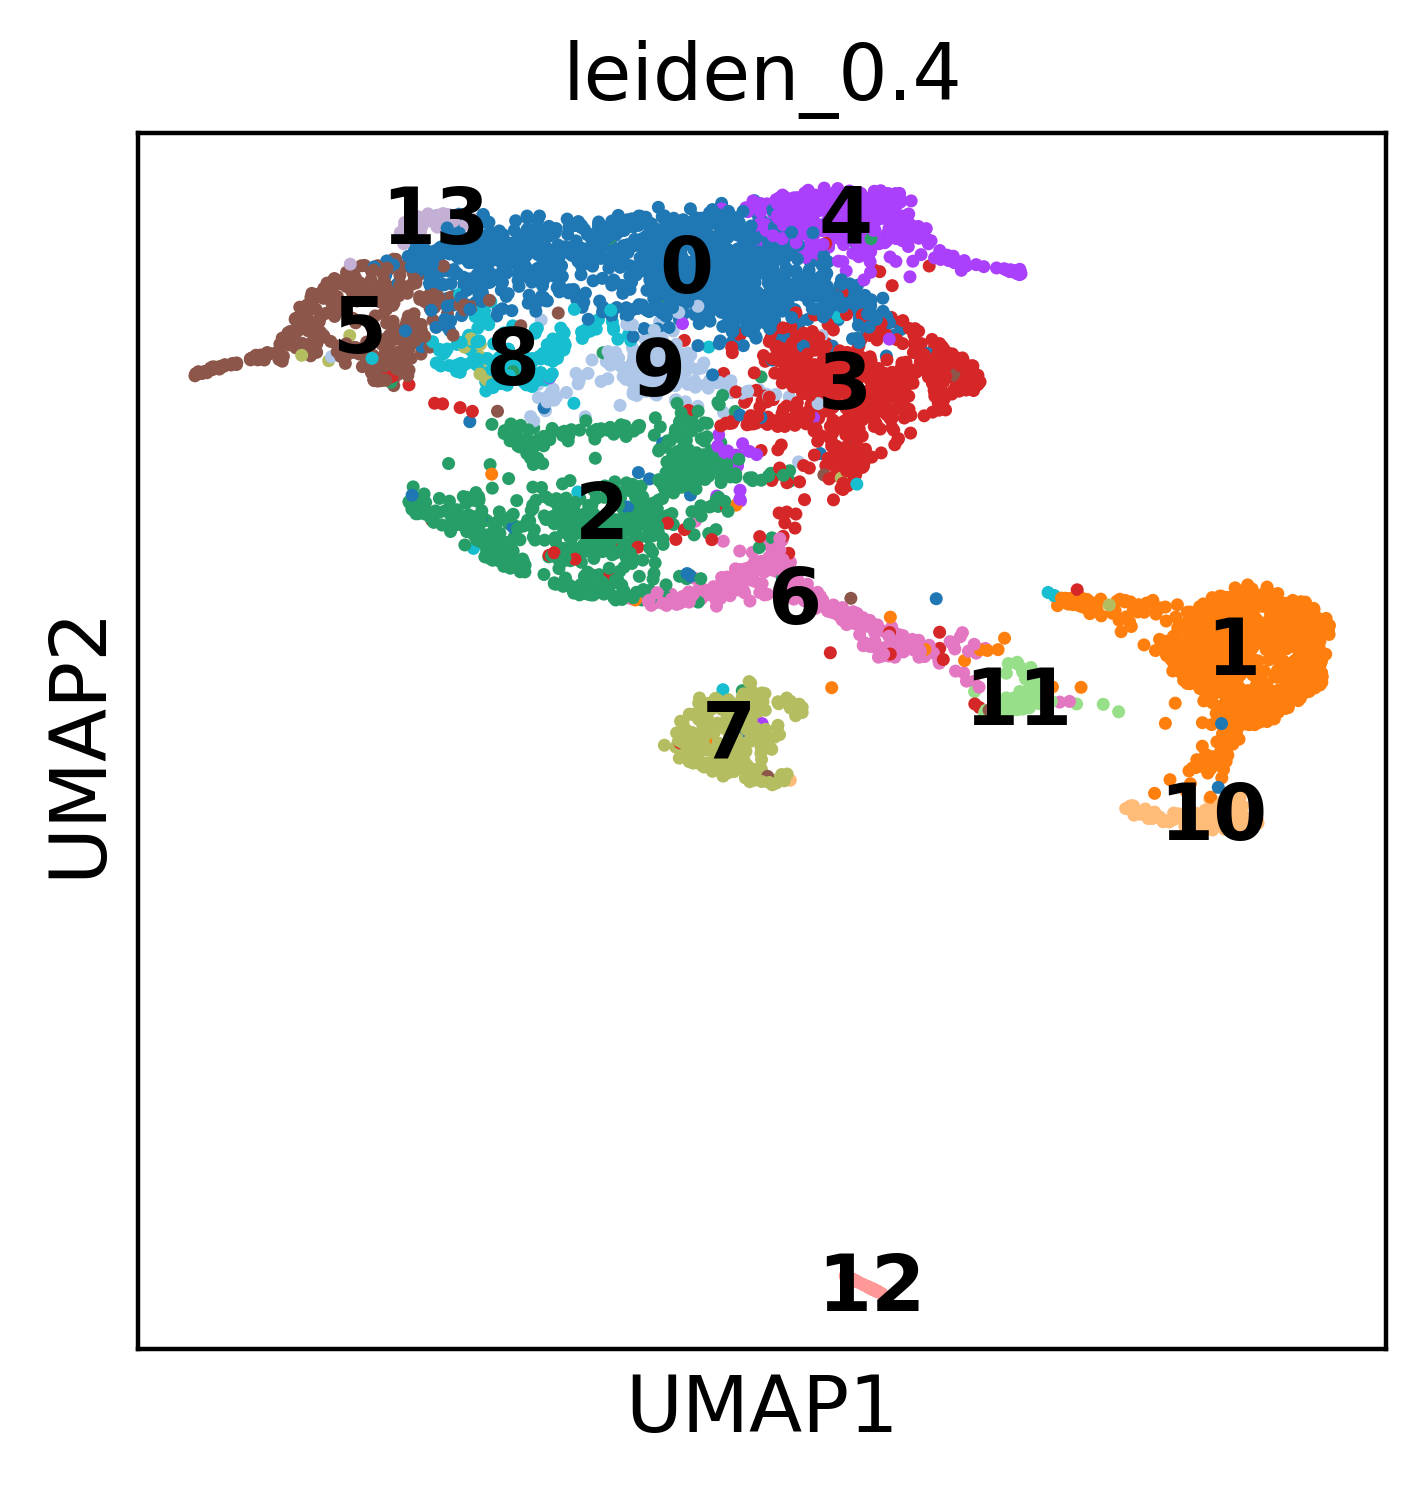

/opt/conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


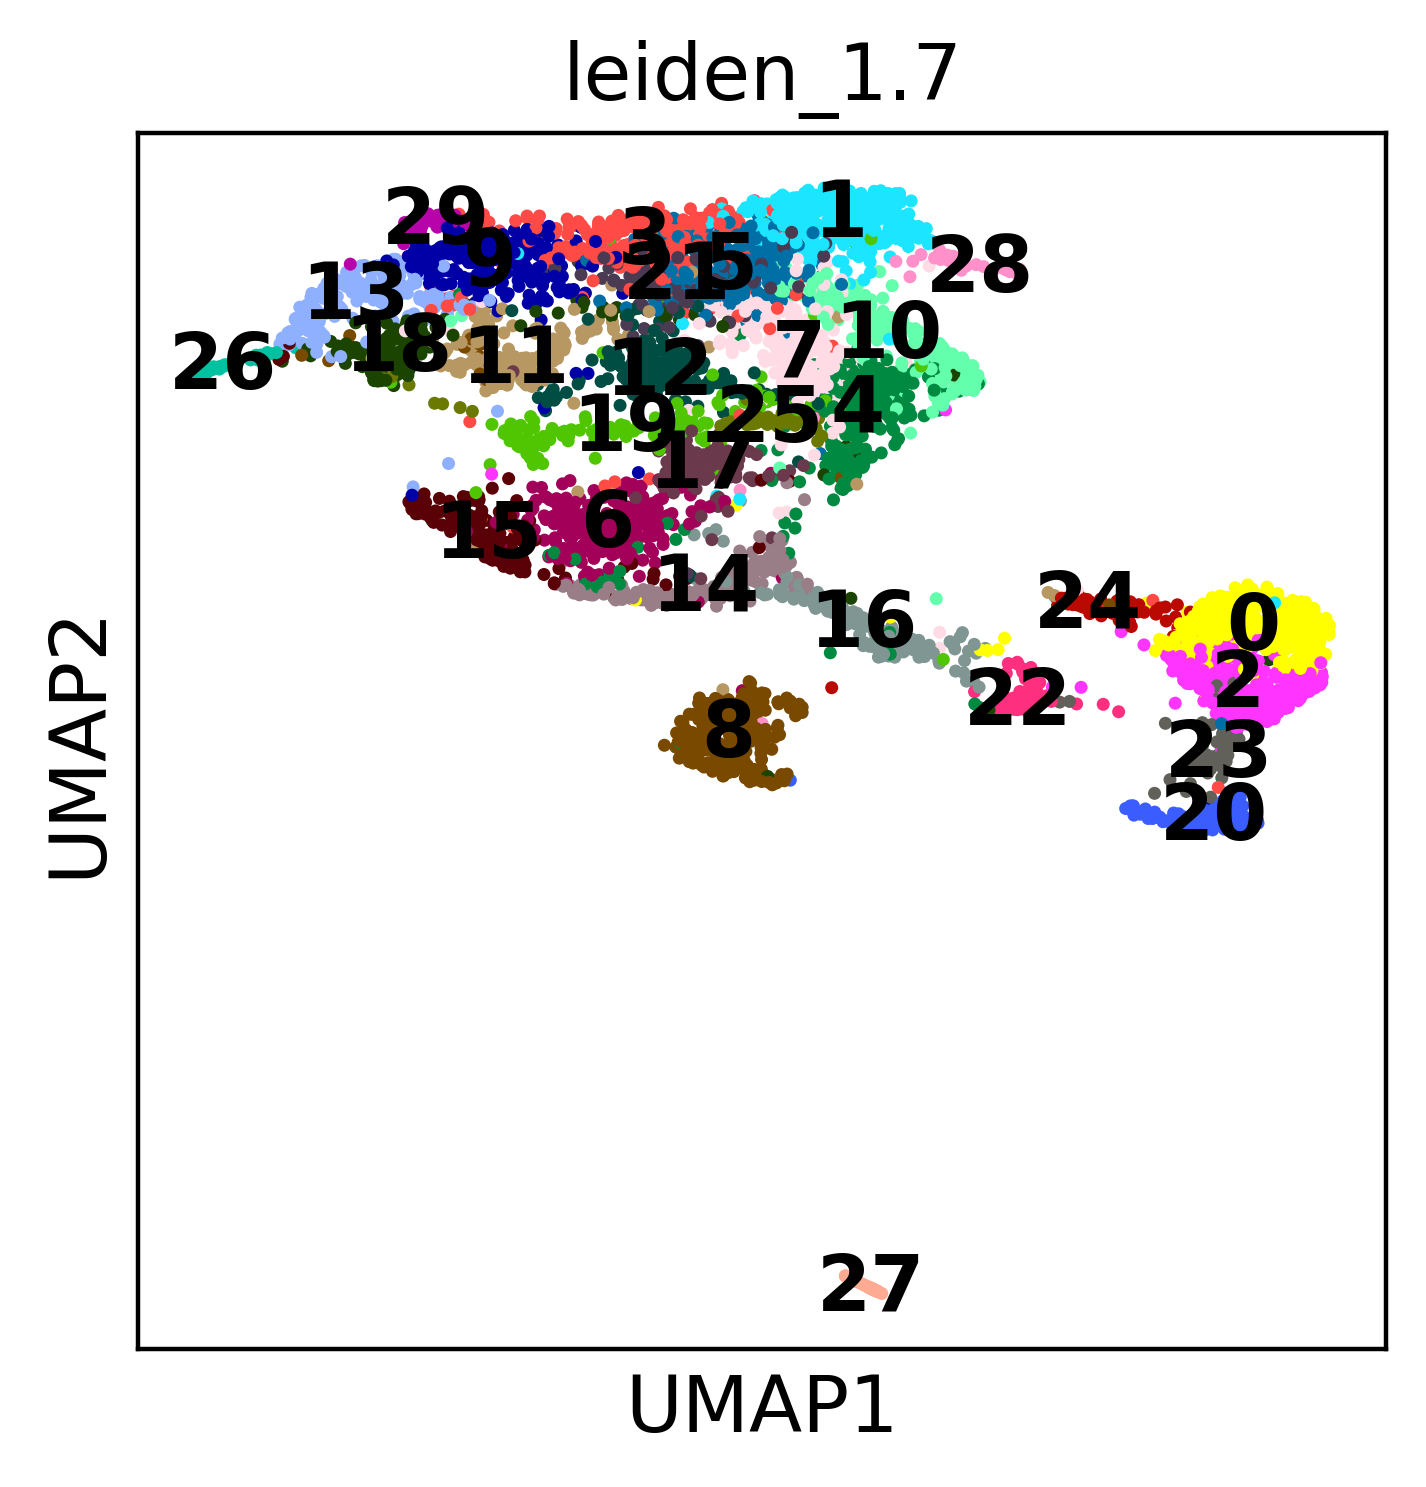

In [27]:
for res in [0.1, 0.38, 0.4, 1.7]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")